# Setup

In this tutorial we use the defaul version of the CTGAN:
https://github.com/sdv-dev/CTGAN

We also need to install table evaluator to evaluate the quality of the generated synthetic data.

In [1]:
!pip install ctgan



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install sdmetrics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Now we download a dataset that includes both continuous and discrete values. I chose a random dataset from Kaggle: https://www.kaggle.com/datasets/mirichoi0218/insurance

In [3]:
import pandas as pd
data = pd.read_csv('insurance.csv')

In [4]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Next, we define a list with column names for categorical variables. This list will be passed to the model so that the model can decide how to process these fields.

In [5]:
categorical_features = ['age','sex','children','smoker','region']

#Model training

Next, we simply define an instance of CTGANSynthesizer and call the fit method with the dataframe and the list of categorical variables.

We train the model for 300 epochs only as the discriminator and generator loss becomes quite low after these many epochs.

In [6]:
from ctgan import CTGAN

ctgan = CTGAN(verbose=True)
ctgan.fit(data, categorical_features, epochs = 200)

Gen. (0.28) | Discrim. (-0.07): 100%|██████████| 200/200 [00:12<00:00, 16.13it/s]


#Synthetic data generation

In [7]:
samples = ctgan.sample(1000)

In [8]:
samples

,age,sex,bmi,children,smoker,region,charges
0,27,male,31.717211,0,no,southwest,6277.402648
1,56,female,37.198181,0,no,northwest,6182.106758
2,37,male,24.915745,0,yes,northwest,16314.517521
3,18,male,51.815449,2,no,southeast,-2430.487835
4,34,female,26.277045,3,no,southeast,36817.358481
...,...,...,...,...,...,...,...
995,18,male,32.433092,4,no,northwest,6307.988398
996,60,male,32.525649,2,no,northeast,4442.583009
997,42,female,38.505398,2,no,northeast,19537.128052
998,56,female,39.189528,0,no,northwest,12721.821633


#Evaluation

In [11]:
from sdmetrics.reports.single_table import QualityReport
from sdv.metadata import SingleTableMetadata

# Build metadata from the real data
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

print("Real data shape:", data.shape)
print("Synthetic data shape:", samples.shape)

# Generate quality report
quality_report = QualityReport()
quality_report.generate(real_data=data, synthetic_data=samples, metadata=metadata.to_dict())

print("\nOverall Quality Score:", quality_report.get_score())

Real data shape: (1338, 7)
Synthetic data shape: (1000, 7)
Generating report ...

(1/2) Evaluating Column Shapes: |          | 0/7 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |██████████| 7/7 [00:00<00:00, 570.55it/s]|
Column Shapes Score: 92.07%

(2/2) Evaluating Column Pair Trends: |██████████| 21/21 [00:00<00:00, 356.44it/s]|
Column Pair Trends Score: 83.82%

Overall Score (Average): 87.95%


Overall Quality Score: 0.8794518628715584


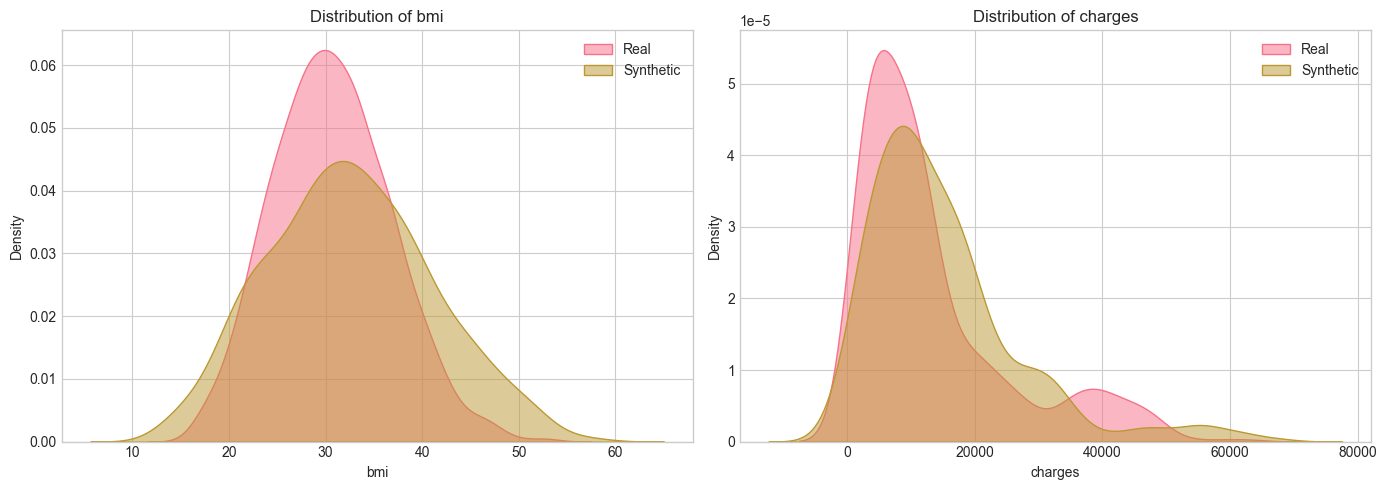

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# --- 1. Distribution comparison for numerical columns ---
numerical_cols = ['bmi', 'charges']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.kdeplot(data[col], ax=ax, label='Real', fill=True, alpha=0.5)
    sns.kdeplot(samples[col], ax=ax, label='Synthetic', fill=True, alpha=0.5)
    ax.set_title(f'Distribution of {col}')
    ax.legend()
plt.tight_layout()
plt.show()

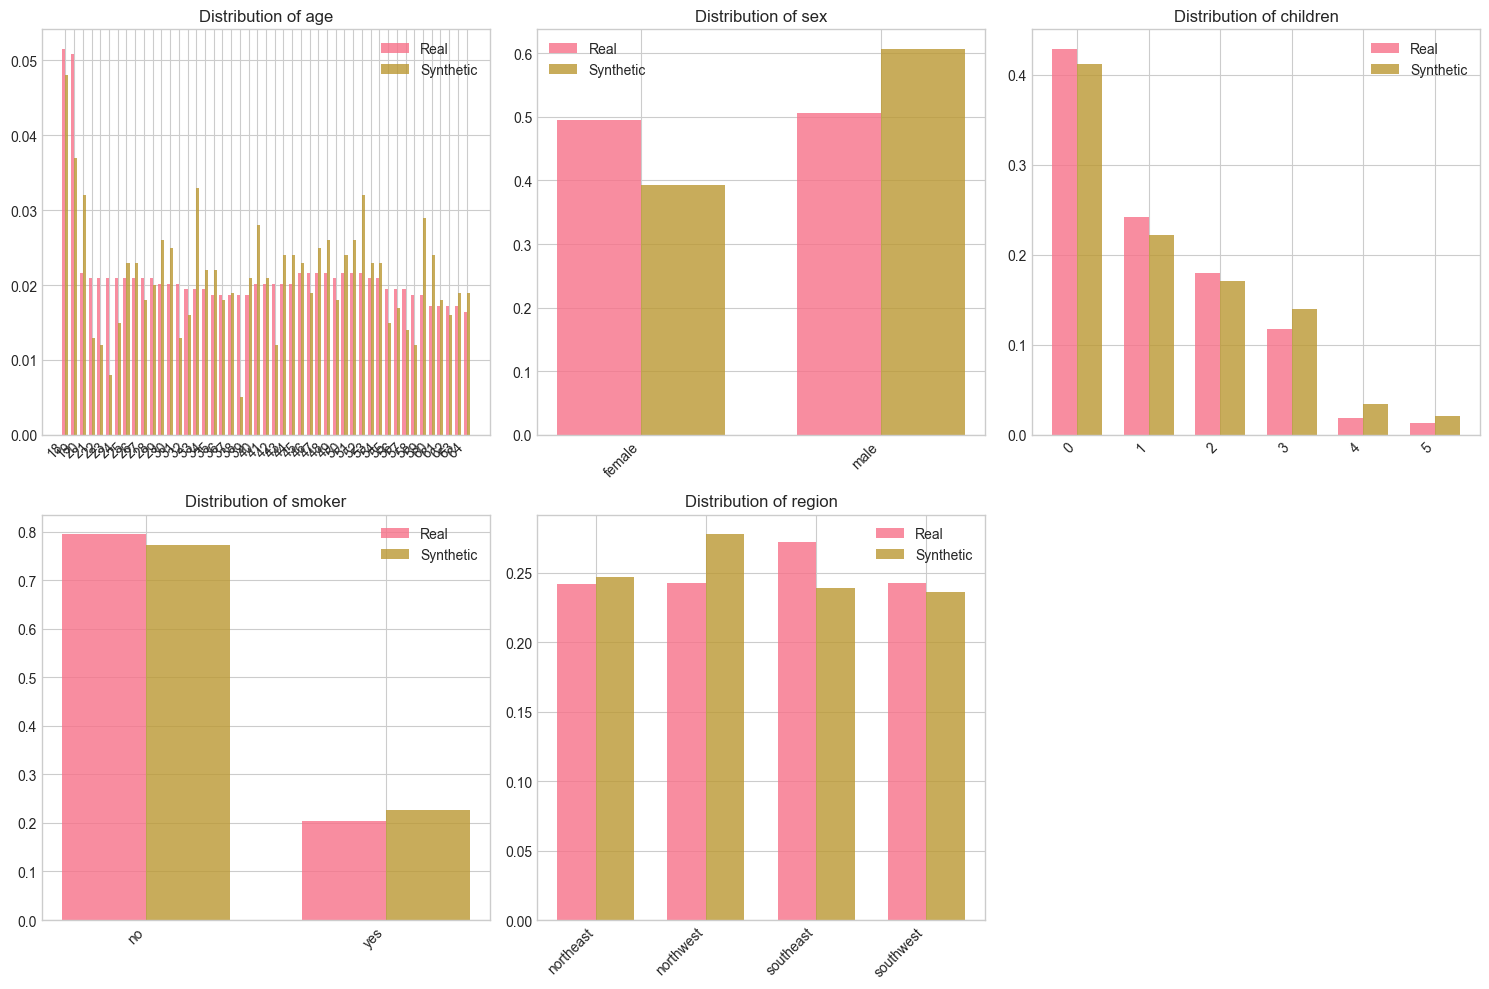

In [16]:
# --- 2. Distribution comparison for categorical columns ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax = axes[i]
    
    # Get value counts normalized
    real_counts = data[col].value_counts(normalize=True).sort_index()
    synth_counts = samples[col].value_counts(normalize=True).sort_index()
    
    # Align indices
    all_categories = sorted(set(real_counts.index) | set(synth_counts.index))
    real_vals = [real_counts.get(cat, 0) for cat in all_categories]
    synth_vals = [synth_counts.get(cat, 0) for cat in all_categories]
    
    x = np.arange(len(all_categories))
    width = 0.35
    
    ax.bar(x - width/2, real_vals, width, label='Real', alpha=0.8)
    ax.bar(x + width/2, synth_vals, width, label='Synthetic', alpha=0.8)
    ax.set_title(f'Distribution of {col}')
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in all_categories], rotation=45, ha='right')
    ax.legend()

# Hide last empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

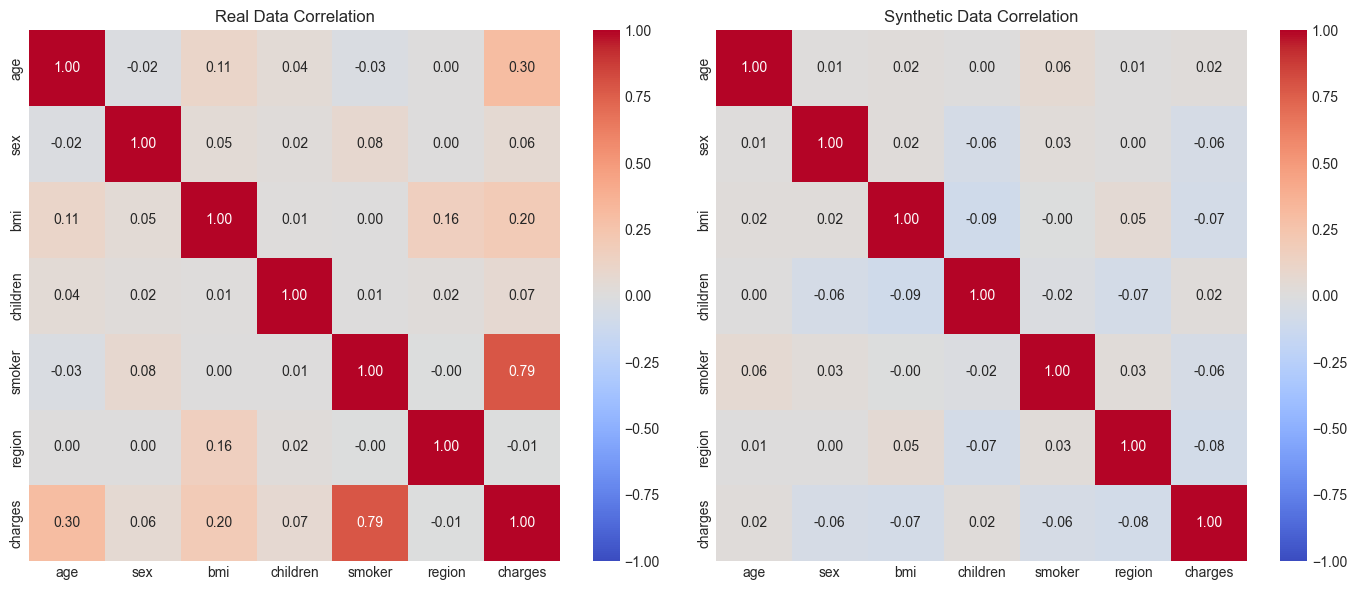

In [17]:
# --- 3. Correlation heatmaps comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Encode categorical columns for correlation
def encode_for_corr(df):
    df_encoded = df.copy()
    for col in categorical_features:
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].astype('category').cat.codes
    return df_encoded

real_encoded = encode_for_corr(data)
synth_encoded = encode_for_corr(samples)

sns.heatmap(real_encoded.corr(), ax=axes[0], cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1)
axes[0].set_title('Real Data Correlation')

sns.heatmap(synth_encoded.corr(), ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1)
axes[1].set_title('Synthetic Data Correlation')

plt.tight_layout()
plt.show()

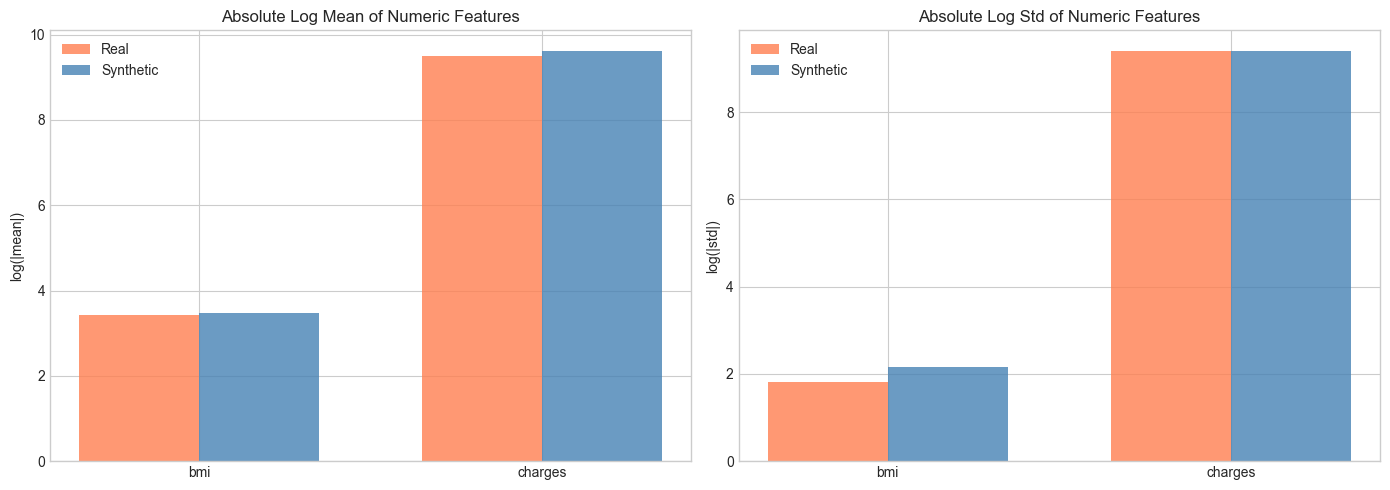


=== Numeric Feature Statistics ===
Feature         Real Mean   Synth Mean     Real Std    Synth Std
------------------------------------------------------------
bmi                 30.66        32.54         6.10         8.56
charges          13270.42     15011.14     12110.01     12131.98


In [21]:
# --- 4. Absolute Log Mean and Std of Numeric Data ---
numerical_cols = ['bmi', 'charges']

# Calculate stats
real_means = data[numerical_cols].mean()
synth_means = samples[numerical_cols].mean()
real_stds = data[numerical_cols].std()
synth_stds = samples[numerical_cols].std()

# Apply absolute log transform (add small epsilon to avoid log(0))
eps = 1e-10
real_log_means = np.log(np.abs(real_means) + eps)
synth_log_means = np.log(np.abs(synth_means) + eps)
real_log_stds = np.log(np.abs(real_stds) + eps)
synth_log_stds = np.log(np.abs(synth_stds) + eps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log Means comparison
x = np.arange(len(numerical_cols))
width = 0.35
axes[0].bar(x - width/2, real_log_means, width, label='Real', alpha=0.8, color='coral')
axes[0].bar(x + width/2, synth_log_means, width, label='Synthetic', alpha=0.8, color='steelblue')
axes[0].set_title('Absolute Log Mean of Numeric Features')
axes[0].set_xticks(x)
axes[0].set_xticklabels(numerical_cols)
axes[0].set_ylabel('log(|mean|)')
axes[0].legend()

# Log Stds comparison
axes[1].bar(x - width/2, real_log_stds, width, label='Real', alpha=0.8, color='coral')
axes[1].bar(x + width/2, synth_log_stds, width, label='Synthetic', alpha=0.8, color='steelblue')
axes[1].set_title('Absolute Log Std of Numeric Features')
axes[1].set_xticks(x)
axes[1].set_xticklabels(numerical_cols)
axes[1].set_ylabel('log(|std|)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print actual values
print("\n=== Numeric Feature Statistics ===")
print(f"{'Feature':<12} {'Real Mean':>12} {'Synth Mean':>12} {'Real Std':>12} {'Synth Std':>12}")
print("-" * 60)
for col in numerical_cols:
    print(f"{col:<12} {real_means[col]:>12.2f} {synth_means[col]:>12.2f} {real_stds[col]:>12.2f} {synth_stds[col]:>12.2f}")

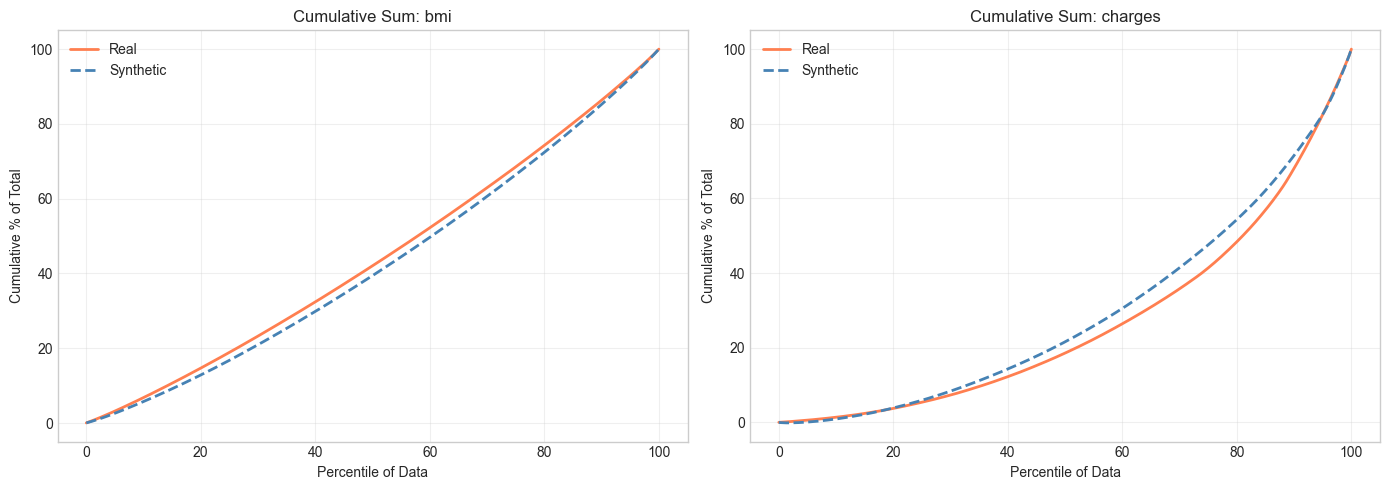

In [22]:
# --- 5. Cumulative Sums per Feature ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    # Sort and compute cumulative sums
    real_sorted = np.sort(data[col].values)
    synth_sorted = np.sort(samples[col].values)
    
    real_cumsum = np.cumsum(real_sorted)
    synth_cumsum = np.cumsum(synth_sorted)
    
    # Normalize to percentage of total
    real_cumsum_pct = real_cumsum / real_cumsum[-1] * 100
    synth_cumsum_pct = synth_cumsum / synth_cumsum[-1] * 100
    
    # Plot
    ax.plot(np.linspace(0, 100, len(real_cumsum_pct)), real_cumsum_pct, 
            label='Real', linewidth=2, color='coral')
    ax.plot(np.linspace(0, 100, len(synth_cumsum_pct)), synth_cumsum_pct, 
            label='Synthetic', linewidth=2, linestyle='--', color='steelblue')
    ax.set_title(f'Cumulative Sum: {col}')
    ax.set_xlabel('Percentile of Data')
    ax.set_ylabel('Cumulative % of Total')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

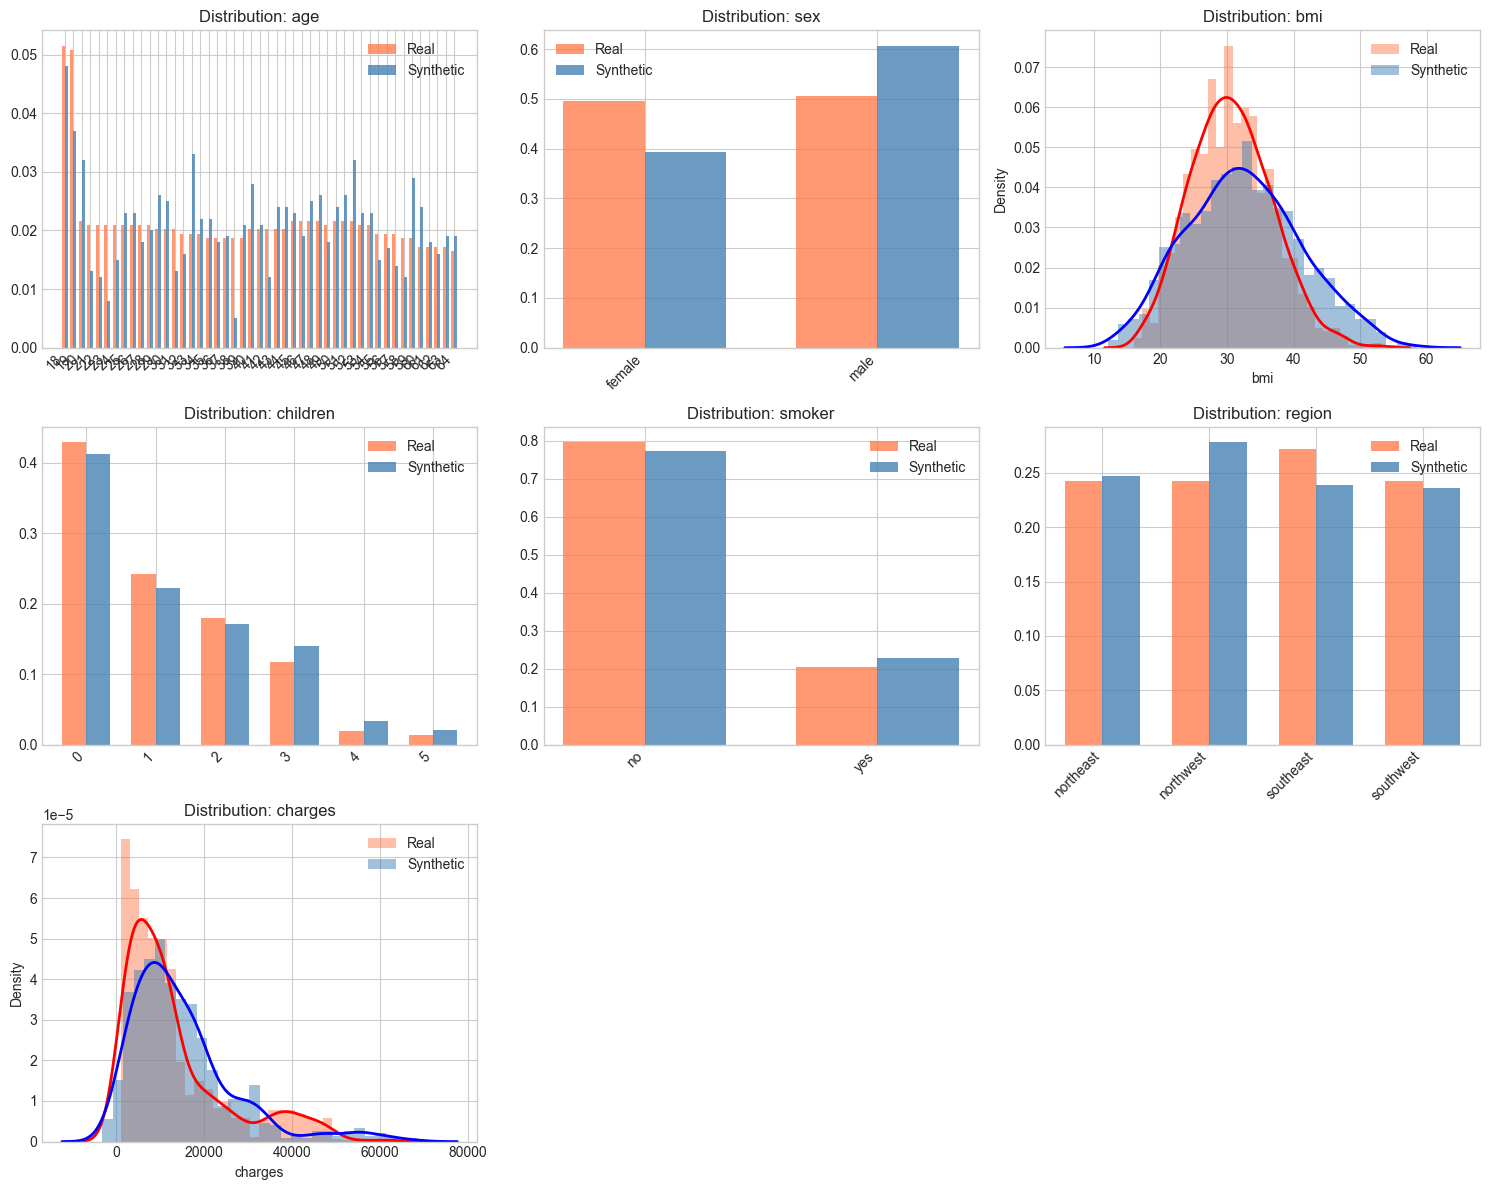

In [23]:
# --- 6. Distribution per Feature (Histogram + KDE overlay) ---
all_cols = data.columns.tolist()
n_cols = len(all_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    
    if col in numerical_cols:
        # For numeric: histogram with KDE
        ax.hist(data[col], bins=30, alpha=0.5, density=True, label='Real', color='coral')
        ax.hist(samples[col], bins=30, alpha=0.5, density=True, label='Synthetic', color='steelblue')
        sns.kdeplot(data[col], ax=ax, color='red', linewidth=2)
        sns.kdeplot(samples[col], ax=ax, color='blue', linewidth=2)
    else:
        # For categorical: bar chart
        real_counts = data[col].value_counts(normalize=True).sort_index()
        synth_counts = samples[col].value_counts(normalize=True).sort_index()
        
        all_categories = sorted(set(real_counts.index) | set(synth_counts.index))
        real_vals = [real_counts.get(cat, 0) for cat in all_categories]
        synth_vals = [synth_counts.get(cat, 0) for cat in all_categories]
        
        x = np.arange(len(all_categories))
        width = 0.35
        ax.bar(x - width/2, real_vals, width, label='Real', alpha=0.8, color='coral')
        ax.bar(x + width/2, synth_vals, width, label='Synthetic', alpha=0.8, color='steelblue')
        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in all_categories], rotation=45, ha='right')
    
    ax.set_title(f'Distribution: {col}')
    ax.legend()

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()